## GAN Implementation from scratch


In [1]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 52.9 MB/s eta 0:00:00


In [2]:
import os

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import MNIST

import matplotlib.pyplot as plt

import pytorch_lightning as pl


random_seed = 42
torch.manual_seed(random_seed)

BATCH_SIZE=128
AVAIL_GPUS = min(1, torch.cuda.device_count())
NUM_WORKERS=int(os.cpu_count() / 2)

In [25]:
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, data_dir="./dataset",
                 batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers

        self.transform = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize((0.1307,), (0.3081,)),
            ]
        )

    def prepare_data(self):
        MNIST(self.data_dir, train=True, download=True)
        MNIST(self.data_dir, train=False, download=True)

    def setup(self, stage=None):
        # Assign train/val datasets
        if stage == "fit" or stage is None:
            mnist_full = MNIST(self.data_dir, train=True, transform=self.transform)
            self.mnist_train, self.mnist_val = random_split(mnist_full, [55000, 5000])

        # Assign test dataset
        if stage == "test" or stage is None:
            self.mnist_test = MNIST(self.data_dir, train=False, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.mnist_train, batch_size=self.batch_size, num_workers=self.num_workers)

    def val_dataloader(self):
        return DataLoader(self.mnist_val, batch_size=self.batch_size, num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(self.mnist_test, batch_size=self.batch_size, num_workers=self.num_workers)

In [4]:
# Detective: fake or no fake -> 1 output [0, 1]
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Simple CNN
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 1)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        # Flatten the tensor so it can be fed into the FC layers
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return torch.sigmoid(x)

In [5]:
# Generate Fake Data: output like real data [1, 28, 28] and values -1, 1
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.lin1 = nn.Linear(latent_dim, 7*7*64)  # [n, 256, 7, 7]
        self.ct1 = nn.ConvTranspose2d(64, 32, 4, stride=2) # [n, 64, 16, 16]
        self.ct2 = nn.ConvTranspose2d(32, 16, 4, stride=2) # [n, 16, 34, 34]
        self.conv = nn.Conv2d(16, 1, kernel_size=7)  # [n, 1, 28, 28]


    def forward(self, x):
        # Pass latent space input into linear layer and reshape
        x = self.lin1(x)
        x = F.relu(x)
        x = x.view(-1, 64, 7, 7)  #256

        # Upsample (transposed conv) 16x16 (64 feature maps)
        x = self.ct1(x)
        x = F.relu(x)

        # Upsample to 34x34 (16 feature maps)
        x = self.ct2(x)
        x = F.relu(x)

        # Convolution to 28x28 (1 feature map)
        return self.conv(x)

In [24]:
class GAN(pl.LightningModule):
    def __init__(self, latent_dim=64, lr=0.0002):
        super().__init__()
        self.latent_dim = latent_dim
        self.lr = lr
        self.generator = Generator(latent_dim)
        self.discriminator = Discriminator()
        self.validation_z = torch.randn(8, latent_dim)
        self.automatic_optimization = False

        self.train_loss_g = []
        self.train_loss_d = []

    def forward(self, z):
        # Generate images from latent noise.
        return self.generator(z)

    def adversarial_loss(self, y_hat, y):
        return F.binary_cross_entropy(y_hat, y)

    def training_step(self, batch, batch_idx):
        real_imgs, _ = batch
        batch_size = real_imgs.size(0)
        device = self.device

        opt_g, opt_d = self.optimizers()

        # Train Discriminator
        z = torch.randn(batch_size, self.latent_dim, device=device)
        fake_imgs = self.generator(z).detach()

        valid = torch.ones(batch_size, 1, device=device)
        fake = torch.zeros(batch_size, 1, device=device)

        real_loss = self.adversarial_loss(self.discriminator(real_imgs), valid)
        fake_loss = self.adversarial_loss(self.discriminator(fake_imgs), fake)
        d_loss = (real_loss + fake_loss) / 2

        opt_d.zero_grad()
        self.manual_backward(d_loss)
        opt_d.step()

        # Train Generator
        z = torch.randn(batch_size, self.latent_dim, device=device)
        gen_imgs = self.generator(z)
        valid = torch.ones(batch_size, 1, device=device)

        g_loss = self.adversarial_loss(self.discriminator(gen_imgs), valid)

        opt_g.zero_grad()
        self.manual_backward(g_loss)
        opt_g.step()

        # Logging
        self.log("g_loss", g_loss, prog_bar=True)
        self.log("d_loss", d_loss, prog_bar=True)
        self.train_loss_g.append(g_loss.item())
        self.train_loss_d.append(d_loss.item())

    def configure_optimizers(self):
        opt_g = optim.Adam(self.generator.parameters(), lr=self.lr)
        opt_d = optim.Adam(self.discriminator.parameters(), lr=self.lr)
        return [opt_g, opt_d]

    def on_train_end(self):
        plt.figure(figsize=(8,4))
        plt.plot(self.train_loss_g, label="Generator Loss")
        plt.plot(self.train_loss_d, label="Discriminator Loss")
        plt.title("Training Loss Curves")
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()

    def on_train_epoch_end(self):
        z = self.validation_z.to(self.device)
        samples = self(z).detach().cpu()
        grid = torchvision.utils.make_grid(samples, nrow=4, normalize=True)
        plt.figure(figsize=(5,5))
        plt.imshow(grid.permute(1, 2, 0))
        plt.title(f"Epoch {self.current_epoch+1}")
        plt.axis("off")
        plt.show()

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | generator     | Generator     | 245 K  | train
1 | discriminator | Discriminator | 21.4 K | train
--------------------------------------------------------
267 K     Trainable params
0         Non-trainable params
267 K     Total params
1.068     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval 

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


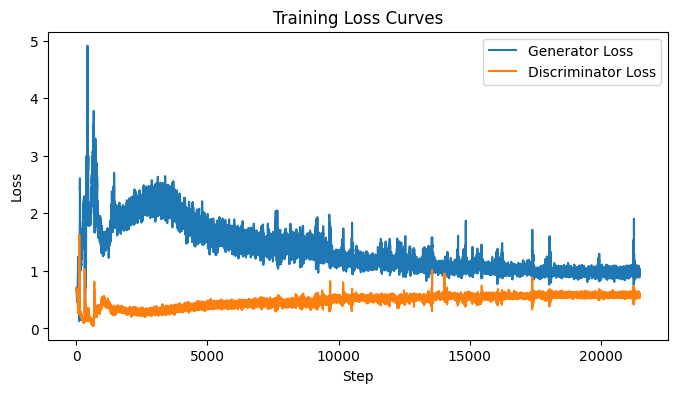

In [21]:
dm = MNISTDataModule()
gan_model = GAN(latent_dim=64)

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
)

trainer.fit(gan_model, datamodule=dm)


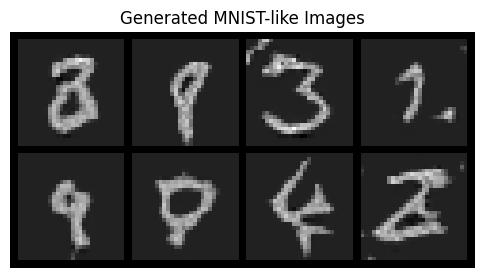

In [23]:
gan_model.eval()
z = torch.randn(8, gan_model.latent_dim)
samples = gan_model(z).detach().cpu()

grid = torchvision.utils.make_grid(samples, nrow=4, normalize=True)
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1, 2, 0))
plt.title("Generated MNIST-like Images")
plt.axis("off")
plt.show()
